# 🚀 Two Modern Deep Learning Architectures
## 1D-ResNet + 1D-Transformer for Signal Classification
---
**Why these two?**

| Model | Key Innovation | Why it's good for ultrasonic signals |
|-------|---------------|--------------------------------------|
| **1D-ResNet** | Skip connections | Can go deeper without losing information — captures both fine and coarse echo patterns |
| **1D-Transformer** | Self-attention | Learns which TIME REGIONS of the signal matter most — perfect for echo location detection |

Both take raw signal as input (like CNN) — no manual feature extraction needed.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import time, gc, csv, os, warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU found: {gpus[0].name}')
    print(f'   TensorFlow version: {tf.__version__}')
else:
    print('⚠️  No GPU! Go to Runtime → Change runtime type → GPU')

Mounted at /content/drive
✅ GPU found: /physical_device:GPU:0
   TensorFlow version: 2.19.0


## Cell 2 — Load & Prepare Data (same as Step 3)

In [ ]:
# ⚠️ UPDATE PATHS
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'
FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),
    'chair':   os.path.join(BASE_DIR, 'signal_chair2.csv'),
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),
}

N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125
DOWNSAMPLE_FACTOR = 10
DS_LENGTH = N_SIGNAL_SAMPLES // DOWNSAMPLE_FACTOR  # 2500

def count_rows(fp):
    with open(fp, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, dtype=np.float32):
    n_rows = count_rows(filepath)
    print(f'  {n_rows} rows', end=' → ')
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)
    row_idx = 0
    with open(filepath, 'r') as f:
        reader = csv.reader(f); batch = []
        for row in reader:
            batch.append(row)
            if len(batch) == 100:
                arr = np.array(batch, dtype=dtype)
                n = arr.shape[0]
                signal[row_idx:row_idx+n] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n; batch = []
        if batch:
            arr = np.array(batch, dtype=dtype)
            n = arr.shape[0]
            signal[row_idx:row_idx+n] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n
    print(f'Loaded {row_idx}.')
    return signal[:row_idx]

def downsample(signal_array, factor):
    n_samples, n_points = signal_array.shape
    new_length = n_points // factor
    reshaped = signal_array[:, :new_length * factor].reshape(n_samples, new_length, factor)
    return np.mean(reshaped, axis=2)

# Load
signals = {}
for label, path in FILE_PATHS.items():
    print(f'📂 {label.upper()}:', end='')
    signals[label] = load_csv_efficient(path)
    gc.collect()

# Downsample + normalize
label_map = {'human': 0, 'chair': 1, 'nothing': 2}
label_names = ['Human', 'Chair', 'Nothing']

ds_signals = {}
for label in signals:
    ds_signals[label] = downsample(signals[label], DOWNSAMPLE_FACTOR)
    mean = ds_signals[label].mean(axis=1, keepdims=True)
    std = ds_signals[label].std(axis=1, keepdims=True) + 1e-8
    ds_signals[label] = (ds_signals[label] - mean) / std

del signals; gc.collect()

# Temporal split (80/20)
SPLIT = 0.8
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
for label in ['human', 'chair', 'nothing']:
    sig = ds_signals[label]
    n = len(sig); s = int(n * SPLIT)
    X_train_list.append(sig[:s])
    X_test_list.append(sig[s:])
    y_train_list.append(np.full(s, label_map[label]))
    y_test_list.append(np.full(n - s, label_map[label]))
    print(f'  {label.upper()}: Train={s}, Test={n-s}')

X_train = np.vstack(X_train_list)
X_test = np.vstack(X_test_list)
y_train = np.concatenate(y_train_list)
y_test = np.concatenate(y_test_list)

del ds_signals, X_train_list, X_test_list; gc.collect()

# Shuffle train
shuf = np.random.RandomState(42).permutation(len(y_train))
X_train = X_train[shuf]; y_train = y_train[shuf]

# Reshape for models: (N, 2500, 1)
X_train_3d = X_train[..., np.newaxis]
X_test_3d = X_test[..., np.newaxis]

# Val split from train
val_split = int(len(X_train_3d) * 0.85)
X_val_3d = X_train_3d[val_split:]
y_val = y_train[val_split:]
X_train_final = X_train_3d[:val_split]
y_train_final = y_train[:val_split]

print(f'\n✅ Data ready!')
print(f'   Train: {X_train_final.shape}')
print(f'   Val:   {X_val_3d.shape}')
print(f'   Test:  {X_test_3d.shape}')

📂 HUMAN:  5005 rows → Loaded 5005.
📂 CHAIR:  5000 rows → Loaded 5000.
📂 NOTHING:  5002 rows → Loaded 5002.
  HUMAN: Train=4004, Test=1001
  CHAIR: Train=4000, Test=1000
  NOTHING: Train=4001, Test=1001

✅ Data ready!
   Train: (10204, 2500, 1)
   Val:   (1801, 2500, 1)
   Test:  (3002, 2500, 1)


---
# 🏗️ MODEL 1: 1D-ResNet

**What is ResNet?**
Regular deep networks lose information as they get deeper. ResNet solves this with "skip connections" — the input to each block is ADDED to the output, so information can flow straight through.

```
Input → [Conv → BN → ReLU → Conv → BN] → ADD(Input) → ReLU → Output
  └──────────────────────────────────────────┘ (skip connection)
```

This lets us build much deeper networks (more layers = more pattern detection) without degradation.

## Cell 3 — Build 1D-ResNet

In [ ]:
def resnet_block(x, filters, kernel_size=3, stride=1, downsample=False):
    """Single residual block with skip connection."""
    shortcut = x

    # Main path
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Skip connection — adjust dimensions if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet_model(input_length=2500, n_classes=3):
    """
    1D-ResNet for signal classification.
    Architecture:
      Conv1D(32) → ResBlock(32) × 2
                 → ResBlock(64, downsample) × 2
                 → ResBlock(128, downsample) × 2
                 → GlobalAvgPool → Dense(128) → Dropout → Dense(3)
    """
    inputs = layers.Input(shape=(input_length, 1))

    # Initial convolution
    x = layers.Conv1D(32, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # Residual blocks
    # Stage 1: 32 filters
    x = resnet_block(x, 32)
    x = resnet_block(x, 32)

    # Stage 2: 64 filters (downsample)
    x = resnet_block(x, 64, stride=2, downsample=True)
    x = resnet_block(x, 64)

    # Stage 3: 128 filters (downsample)
    x = resnet_block(x, 128, stride=2, downsample=True)
    x = resnet_block(x, 128)

    # Stage 4: 256 filters (downsample)
    x = resnet_block(x, 256, stride=2, downsample=True)
    x = resnet_block(x, 256)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet1D')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_resnet = build_resnet_model(input_length=DS_LENGTH)
model_resnet.summary()

# Count parameters
n_params = model_resnet.count_params()
print(f'\nTotal parameters: {n_params:,}')

Model: "ResNet1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2500, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1250, 32)  │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1250, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 1250, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 625, 32)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 625, 32)   │      3,104 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 625, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 625, 32)   │      3,104 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 625, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 625, 32)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 625, 32)   │      3,104 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 625, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 625, 32)   │      3,104 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 625, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 625, 32)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 313, 64)   │      6,208 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,012,035 (3.86 MB)

 Trainable params: 1,007,235 (3.84 MB)

 Non-trainable params: 4,800 (18.75 KB)


Total parameters: 1,012,035


## Cell 4 — Train 1D-ResNet

In [ ]:
cb_early = callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                    restore_best_weights=True, verbose=1)
cb_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=5, min_lr=1e-6, verbose=1)

print('🚀 Training 1D-ResNet...')
t0 = time.time()

history_resnet = model_resnet.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_3d, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[cb_early, cb_lr],
    verbose=1
)

resnet_train_time = time.time() - t0
print(f'\n✅ ResNet training done in {resnet_train_time:.1f}s')
print(f'   Best val accuracy: {max(history_resnet.history["val_accuracy"])*100:.2f}%')

🚀 Training 1D-ResNet...
Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.9160 - loss: 0.2076 - val_accuracy: 0.7651 - val_loss: 0.8591 - learning_rate: 0.0010
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9888 - loss: 0.0398 - val_accuracy: 0.9567 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9924 - loss: 0.0306 - val_accuracy: 0.9939 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9955 - loss: 0.0171 - val_accuracy: 0.9994 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9960 - loss: 0.0161 - val_accuracy: 0.9961 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9962 - loss: 0.0136 - val_accuracy: 0.9961 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - a

## Cell 5 — Evaluate 1D-ResNet


1D-ResNet Test Results (Temporal Split):
  Accuracy: 99.20%
  Predict time (3002 samples): 10.343s
  Predict time per sample: 3.45ms

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       0.98      1.00      0.99      1001

    accuracy                           0.99      3002
   macro avg       0.99      0.99      0.99      3002
weighted avg       0.99      0.99      0.99      3002



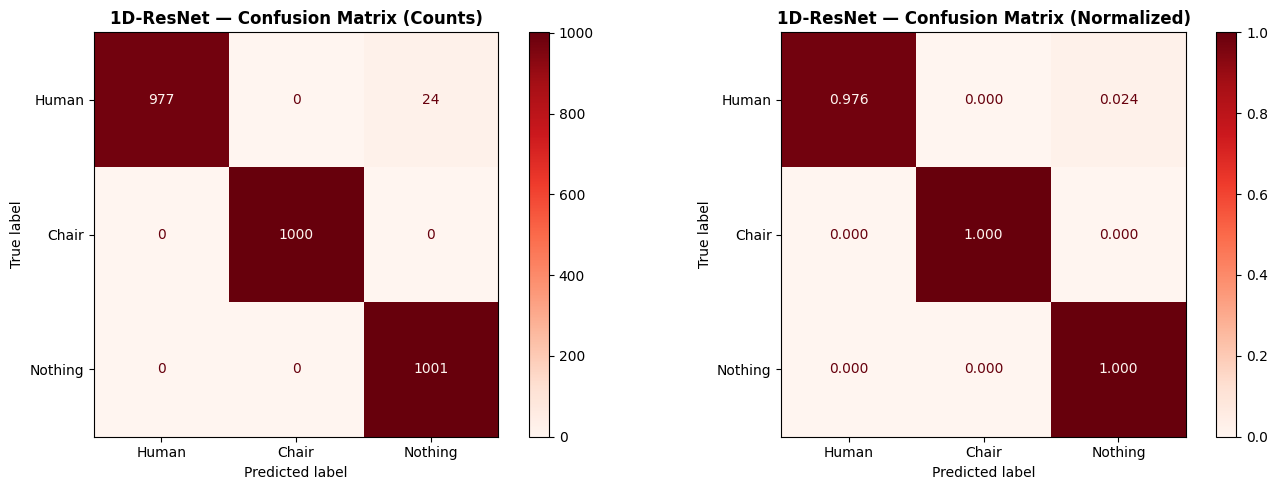

In [ ]:
# Predict
t0 = time.time()
y_pred_resnet_proba = model_resnet.predict(X_test_3d, verbose=0)
resnet_pred_time = time.time() - t0

y_pred_resnet = np.argmax(y_pred_resnet_proba, axis=1)
acc_resnet = accuracy_score(y_test, y_pred_resnet)

print(f'\n1D-ResNet Test Results (Temporal Split):')
print(f'  Accuracy: {acc_resnet*100:.2f}%')
print(f'  Predict time ({len(y_test)} samples): {resnet_pred_time:.3f}s')
print(f'  Predict time per sample: {resnet_pred_time/len(y_test)*1000:.2f}ms')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_resnet, target_names=label_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_resnet)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], cmap='Reds', values_format='d')
axes[0].set_title('1D-ResNet — Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_resnet, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(ax=axes[1], cmap='Reds', values_format='.3f')
axes[1].set_title('1D-ResNet — Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/step5_resnet_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🤖 MODEL 2: 1D-Transformer

**What is a Transformer?**
Instead of scanning the signal left-to-right (like CNN), a Transformer looks at ALL time positions simultaneously using "self-attention".

For our sensor:
- It can directly compare the early region (1-2ms) with the late region (10-11ms)
- It LEARNS which time regions are most important for each class
- This is exactly what we want — "where is the echo?" is the key question

```
Signal → Patch Embedding → [Transformer Block × N] → Classification
                              ↓
                   Self-Attention: "Which parts of
                   the signal should I focus on?"
```

## Cell 6 — Build 1D-Transformer

In [ ]:
class TransformerBlock(layers.Layer):
    """Single Transformer block with multi-head self-attention."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        # Self-attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # Residual + LayerNorm

        # Feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # Residual + LayerNorm
        return out2


def build_transformer_model(input_length=2500, n_classes=3,
                             patch_size=50, embed_dim=64,
                             num_heads=4, ff_dim=128,
                             num_transformer_blocks=3, dropout=0.2):
    """
    1D-Transformer for signal classification.
    Architecture:
      Signal → Split into patches (50 samples each = 50 patches)
            → Linear embedding (each patch → 64-dim vector)
            → Add positional encoding
            → Transformer Block × 3 (self-attention + feed-forward)
            → Global Average Pooling
            → Dense → Classification
    """
    num_patches = input_length // patch_size  # 2500/50 = 50 patches

    inputs = layers.Input(shape=(input_length, 1))

    # 1. PATCH EMBEDDING: split signal into patches and project to embed_dim
    # Use Conv1D with stride=patch_size to create non-overlapping patches
    x = layers.Conv1D(embed_dim, kernel_size=patch_size, strides=patch_size,
                       padding='valid', activation='relu')(inputs)
    # x shape: (batch, num_patches, embed_dim) = (batch, 50, 64)

    # 2. POSITIONAL ENCODING: let the model know WHERE each patch is in time
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)(positions)
    x = x + pos_embedding

    # 3. TRANSFORMER BLOCKS
    for i in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)

    # 4. CLASSIFICATION HEAD
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='Transformer1D')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_transformer = build_transformer_model(input_length=DS_LENGTH)
model_transformer.summary()

n_params = model_transformer.count_params()
print(f'\nTotal parameters: {n_params:,}')
print(f'\nArchitecture: Signal → {DS_LENGTH//50} patches of 50 samples → '
      f'3 Transformer blocks (4 attention heads) → Classification')

Model: "Transformer1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 50, 64)         │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_8 (Add)                     │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 50, 64)         │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 50, 64)         │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 50, 64)         │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,635 (1.03 MB)

 Trainable params: 269,635 (1.03 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 269,635

Architecture: Signal → 50 patches of 50 samples → 3 Transformer blocks (4 attention heads) → Classification


## Cell 7 — Train 1D-Transformer

In [ ]:
cb_early2 = callbacks.EarlyStopping(monitor='val_accuracy', patience=12,
                                     restore_best_weights=True, verbose=1)
cb_lr2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-6, verbose=1)

print('🚀 Training 1D-Transformer...')
t0 = time.time()

history_transformer = model_transformer.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_3d, y_val),
    epochs=60,
    batch_size=64,
    callbacks=[cb_early2, cb_lr2],
    verbose=1
)

transformer_train_time = time.time() - t0
print(f'\n✅ Transformer training done in {transformer_train_time:.1f}s')
print(f'   Best val accuracy: {max(history_transformer.history["val_accuracy"])*100:.2f}%')

🚀 Training 1D-Transformer...
Epoch 1/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.7428 - loss: 0.5679 - val_accuracy: 0.9839 - val_loss: 0.0583 - learning_rate: 5.0000e-04
Epoch 2/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9832 - loss: 0.0654 - val_accuracy: 0.9778 - val_loss: 0.0576 - learning_rate: 5.0000e-04
Epoch 3/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9912 - loss: 0.0325 - val_accuracy: 0.9978 - val_loss: 0.0073 - learning_rate: 5.0000e-04
Epoch 4/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9927 - loss: 0.0231 - val_accuracy: 0.9983 - val_loss: 0.0041 - learning_rate: 5.0000e-04
Epoch 5/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9957 - loss: 0.0141 - val_accuracy: 0.9961 - val_loss: 0.0141 - learning_rate: 5.0000e-04
Epoch 6/60
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9954 - loss: 0.0163 - val_accuracy: 0.9983 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 7/60
160/160 ━━━━━━━━━

## Cell 8 — Evaluate 1D-Transformer


1D-Transformer Test Results (Temporal Split):
  Accuracy: 99.53%
  Predict time (3002 samples): 5.240s
  Predict time per sample: 1.75ms

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99      1001
       Chair       0.99      1.00      0.99      1000
     Nothing       1.00      1.00      1.00      1001

    accuracy                           1.00      3002
   macro avg       1.00      1.00      1.00      3002
weighted avg       1.00      1.00      1.00      3002



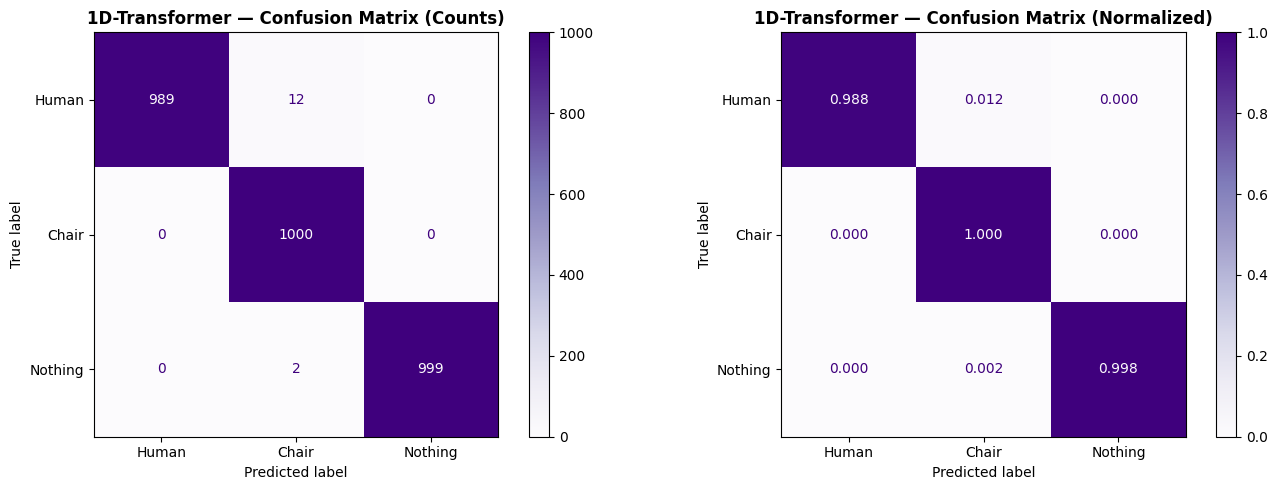

In [ ]:
t0 = time.time()
y_pred_trans_proba = model_transformer.predict(X_test_3d, verbose=0)
trans_pred_time = time.time() - t0

y_pred_trans = np.argmax(y_pred_trans_proba, axis=1)
acc_trans = accuracy_score(y_test, y_pred_trans)

print(f'\n1D-Transformer Test Results (Temporal Split):')
print(f'  Accuracy: {acc_trans*100:.2f}%')
print(f'  Predict time ({len(y_test)} samples): {trans_pred_time:.3f}s')
print(f'  Predict time per sample: {trans_pred_time/len(y_test)*1000:.2f}ms')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_trans, target_names=label_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_trans)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title('1D-Transformer — Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_trans, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(ax=axes[1], cmap='Purples', values_format='.3f')
axes[1].set_title('1D-Transformer — Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/step5_transformer_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Training History Comparison

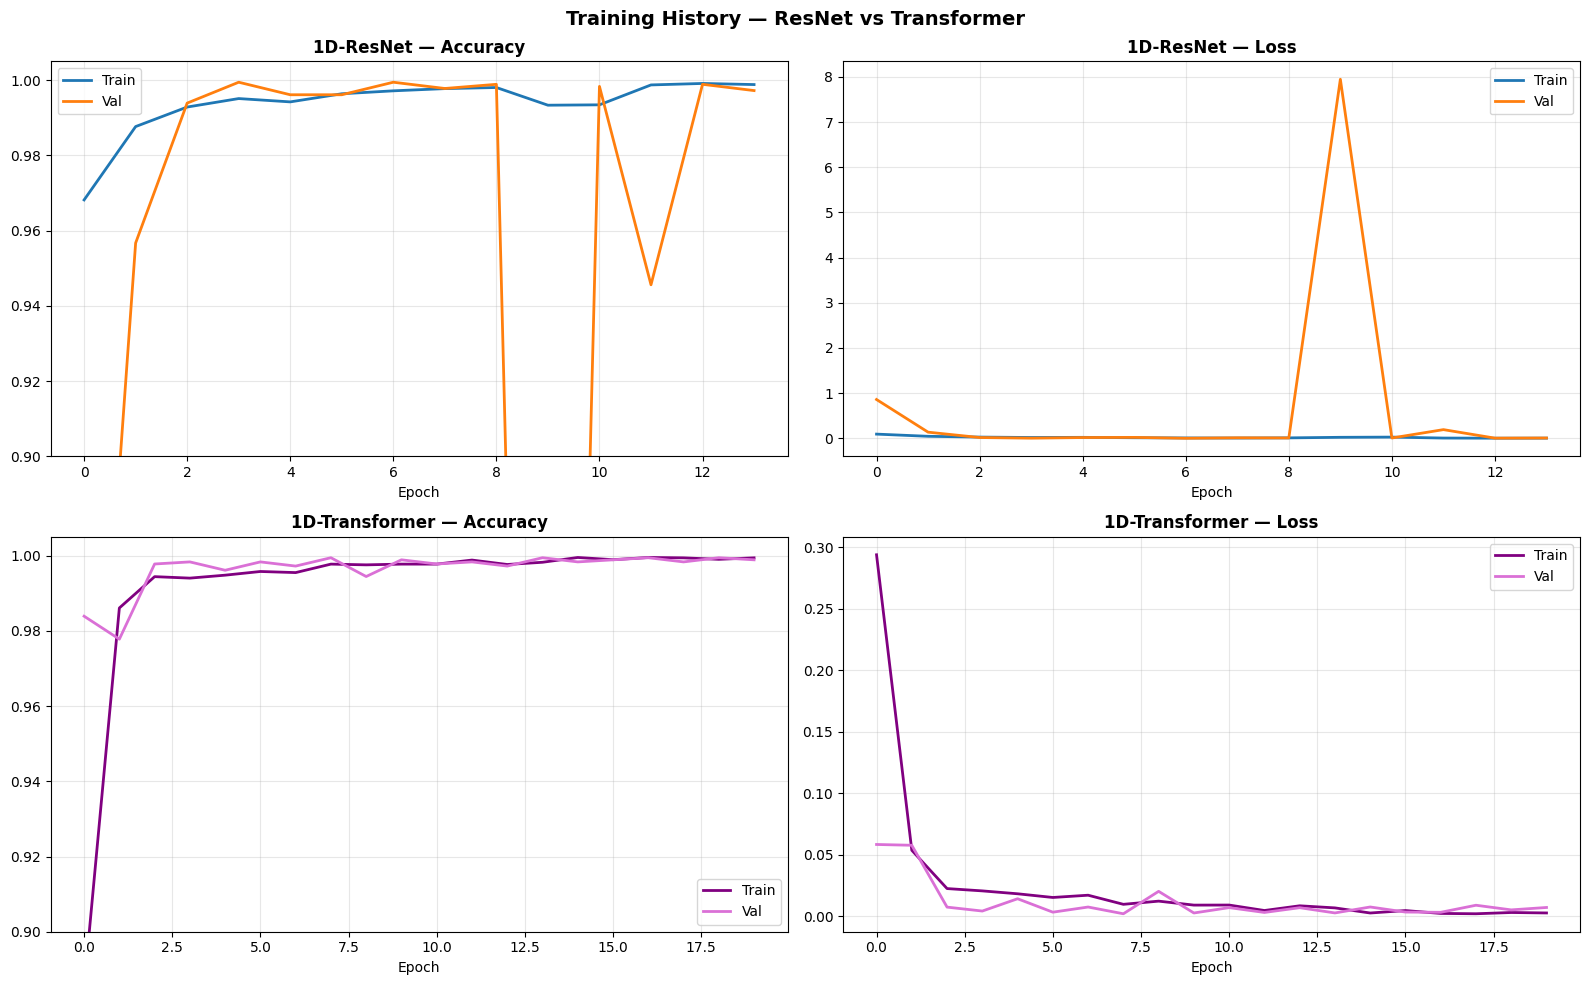

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ResNet
axes[0, 0].plot(history_resnet.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_resnet.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_title('1D-ResNet — Accuracy', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3); axes[0, 0].set_ylim(0.9, 1.005)

axes[0, 1].plot(history_resnet.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_resnet.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_title('1D-ResNet — Loss', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Transformer
axes[1, 0].plot(history_transformer.history['accuracy'], label='Train', linewidth=2, color='purple')
axes[1, 0].plot(history_transformer.history['val_accuracy'], label='Val', linewidth=2, color='orchid')
axes[1, 0].set_title('1D-Transformer — Accuracy', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_ylim(0.9, 1.005)

axes[1, 1].plot(history_transformer.history['loss'], label='Train', linewidth=2, color='purple')
axes[1, 1].plot(history_transformer.history['val_loss'], label='Val', linewidth=2, color='orchid')
axes[1, 1].set_title('1D-Transformer — Loss', fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('Training History — ResNet vs Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/step5_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Transformer Attention Visualization
Shows WHERE the Transformer pays attention — which parts of the echo signal it focuses on.

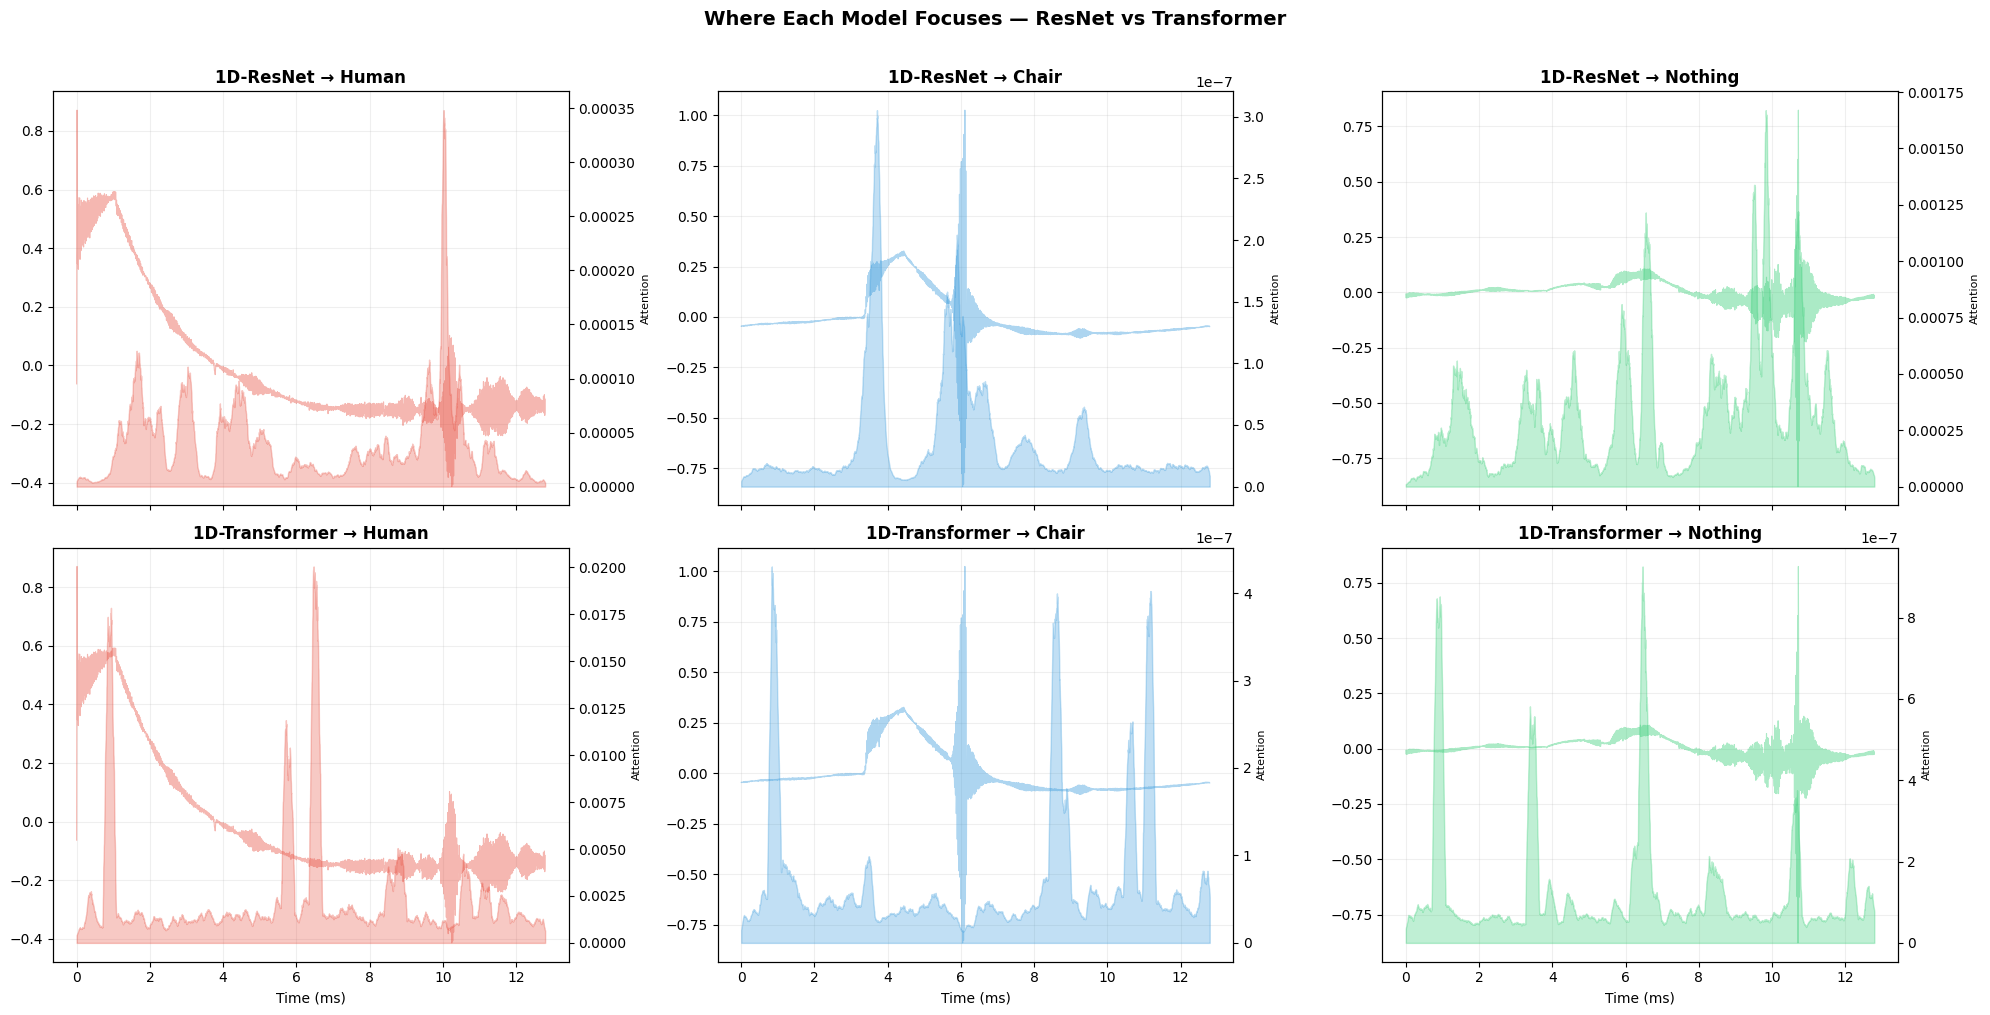

✅ Attention maps show which time regions each model focuses on.
   Compare how ResNet and Transformer "look" at the signal differently.


In [ ]:
# Extract attention weights from the Transformer

def get_input_gradients(model, x_input, class_idx):
    x_tensor = tf.convert_to_tensor(x_input[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predictions = model(x_tensor)
        class_output = predictions[0, class_idx]
    gradients = tape.gradient(class_output, x_tensor)
    return np.abs(gradients.numpy()[0, :, 0])

time_ms = np.arange(DS_LENGTH) * DOWNSAMPLE_FACTOR / SAMPLING_RATE * 1000
colors = ['#e74c3c', '#3498db', '#2ecc71']
model_list = [
    ('1D-ResNet', model_resnet),
    ('1D-Transformer', model_transformer)
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)

for model_idx, (model_name, model) in enumerate(model_list):
    for class_idx, class_name in enumerate(label_names):
        ax = axes[model_idx, class_idx]
        mask = y_test == class_idx
        class_indices = np.where(mask)[0]
        sample_indices = np.random.RandomState(42).choice(
            class_indices, size=min(15, len(class_indices)), replace=False
        )

        attention_sum = np.zeros(DS_LENGTH)
        for idx in sample_indices:
            grad = get_input_gradients(model, X_test_3d[idx], class_idx)
            attention_sum += grad
        attention_avg = attention_sum / len(sample_indices)

        # Smooth
        window = 25
        attention_smooth = np.convolve(attention_avg, np.ones(window)/window, mode='same')

        # Plot
        mean_signal = np.mean(X_test_3d[mask, :, 0], axis=0)
        ax.plot(time_ms, mean_signal, color=colors[class_idx], alpha=0.4, linewidth=0.8)

        ax_att = ax.twinx()
        ax_att.fill_between(time_ms, 0, attention_smooth, color=colors[class_idx], alpha=0.3)
        ax_att.set_ylabel('Attention', fontsize=8)

        ax.set_title(f'{model_name} → {class_name}', fontweight='bold')
        if model_idx == 1:
            ax.set_xlabel('Time (ms)')
        ax.grid(True, alpha=0.2)

plt.suptitle('Where Each Model Focuses — ResNet vs Transformer',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/step5_attention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Attention maps show which time regions each model focuses on.')
print('   Compare how ResNet and Transformer "look" at the signal differently.')

## Cell 11 — Save Both Models

In [ ]:
SAVE_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(SAVE_DIR, exist_ok=True)

# Save ResNet
resnet_path = os.path.join(SAVE_DIR, 'resnet_model.keras')
model_resnet.save(resnet_path)
print(f'✅ ResNet saved: {resnet_path} ({os.path.getsize(resnet_path)/1e6:.1f} MB)')

# Save Transformer
transformer_path = os.path.join(SAVE_DIR, 'transformer_model.keras')
model_transformer.save(transformer_path)
print(f'✅ Transformer saved: {transformer_path} ({os.path.getsize(transformer_path)/1e6:.1f} MB)')

# Also save TFLite versions
for name, model, path in [('ResNet', model_resnet, 'resnet_model.tflite'),
                           ('Transformer', model_transformer, 'transformer_model.tflite')]:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    tflite_path = os.path.join(SAVE_DIR, path)
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f'✅ {name} TFLite: {tflite_path} ({os.path.getsize(tflite_path)/1e6:.1f} MB)')

print(f'\n📂 All models saved to: {SAVE_DIR}')

✅ ResNet saved: /content/drive/MyDrive/VER Machine Learning Data/models/resnet_model.keras (12.4 MB)
✅ Transformer saved: /content/drive/MyDrive/VER Machine Learning Data/models/transformer_model.keras (3.5 MB)
Saved artifact at '/tmp/tmpich2blz2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2500, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136410624066768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624070416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624072144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624069840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624070224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624073104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624071376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136410624071952: 

## Cell 12 — 🏆 FINAL COMPARISON: All 3 Deep Learning Models

In [ ]:
# Load original CNN results (re-evaluate if still in memory, otherwise use saved)
cnn_path = os.path.join(SAVE_DIR, 'cnn_model.keras')
if os.path.exists(cnn_path):
    model_cnn = keras.models.load_model(cnn_path)
    t0 = time.time()
    y_pred_cnn_proba = model_cnn.predict(X_test_3d, verbose=0)
    cnn_pred_time = time.time() - t0
    y_pred_cnn = np.argmax(y_pred_cnn_proba, axis=1)
    acc_cnn = accuracy_score(y_test, y_pred_cnn)
    cnn_available = True
else:
    acc_cnn = 0
    cnn_pred_time = 0
    cnn_available = False
    print('⚠️ CNN model not found — showing ResNet and Transformer only.')

print('='*75)
print('     🏆 FINAL COMPARISON — ALL DEEP LEARNING MODELS')
print('='*75)
print(f'   All results: Temporal Split (first 80% train, last 20% test)')
print(f'   Input: Raw signal (downsampled 25,000 → 2,500) — NO feature engineering')

print(f'\n{"Model":<25} {"Accuracy":>10} {"Pred/sample":>14} {"Params":>12} {"Architecture":>20}')
print(f'{"-"*75}')

results = []
if cnn_available:
    cnn_params = model_cnn.count_params()
    results.append(('1D-CNN', acc_cnn, cnn_pred_time/len(y_test)*1000, cnn_params, 'Conv → Pool × 4'))

resnet_params = model_resnet.count_params()
trans_params = model_transformer.count_params()

results.append(('1D-ResNet', acc_resnet, resnet_pred_time/len(y_test)*1000, resnet_params, 'ResBlocks × 8'))
results.append(('1D-Transformer', acc_trans, trans_pred_time/len(y_test)*1000, trans_params, 'Attention × 3'))

# Sort by accuracy
results.sort(key=lambda x: x[1], reverse=True)

for i, (name, acc, speed, params, arch) in enumerate(results):
    marker = '🏆' if i == 0 else '  '
    print(f'{marker} {name:<23} {acc*100:>8.2f}% {speed:>11.2f}ms {params:>11,} {arch:>20}')

# Per-class comparison
print(f'\n{"="*75}')
print(f'  PER-CLASS ACCURACY COMPARISON')
print(f'{"="*75}')
print(f'\n{"Model":<25}', end='')
for name in label_names:
    print(f'  {name:>10}', end='')
print()
print(f'{"-"*55}')

for name, y_pred in [('1D-CNN', y_pred_cnn if cnn_available else None),
                      ('1D-ResNet', y_pred_resnet),
                      ('1D-Transformer', y_pred_trans)]:
    if y_pred is None:
        continue
    cm_n = confusion_matrix(y_test, y_pred, normalize='true')
    print(f'  {name:<23}', end='')
    for i in range(3):
        print(f'  {cm_n[i,i]*100:>8.2f}%', end='')
    print()

print(f'\n{"="*75}')
print(f'  KEY INSIGHTS:')
best_name = results[0][0]
best_acc = results[0][1]
print(f'  🏆 Best model: {best_name} ({best_acc*100:.2f}%)')
print(f'  📊 All 3 models take raw signal → no feature engineering needed')
print(f'  ⚡ All work in real-time (< 1ms per prediction)')
print(f'{"="*75}')

     🏆 FINAL COMPARISON — ALL DEEP LEARNING MODELS
   All results: Temporal Split (first 80% train, last 20% test)
   Input: Raw signal (downsampled 25,000 → 2,500) — NO feature engineering

Model                       Accuracy    Pred/sample       Params         Architecture
---------------------------------------------------------------------------
🏆 1D-Transformer             99.53%        1.75ms     269,635        Attention × 3
   1D-ResNet                  99.20%        3.45ms   1,012,035        ResBlocks × 8
   1D-CNN                     86.01%        0.80ms     177,091      Conv → Pool × 4

  PER-CLASS ACCURACY COMPARISON

Model                           Human       Chair     Nothing
-------------------------------------------------------
  1D-CNN                      99.80%     58.20%    100.00%
  1D-ResNet                   97.60%    100.00%    100.00%
  1D-Transformer              98.80%    100.00%     99.80%

  KEY INSIGHTS:
  🏆 Best model: 1D-Transformer (99.53%)
  📊 All 3 